# ABI

$\Xi$

In [345]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List
from tqdm import tqdm

In [346]:
def prospect_value_function(x: float, alpha=0.8, beta=0.8, lam=2.25) -> float:
    if x >= 0:
        return x ** alpha
    
    return -lam * ((-x) ** beta)

In [347]:
def prospect_np(x: np.array, alpha: float=0.8, beta: float=0.8, lam: float=2.25) -> np.array:
    res = np.zeros_like(x, dtype=float)

    pos = x >= 0
    neg = x < 0

    res[pos] = x[pos] ** alpha
    res[neg] = -lam * ((-x[neg]) ** beta)

    return res

In [348]:
def softmax(x: np.array) -> np.array:
    exp_input = np.exp(x)
    exp_input_sum = np.sum(exp_input)

    return exp_input / exp_input_sum

In [349]:
class Provider:
    def __init__(self, name: str, p: np.array):
        self.name = name
        self.p = p

    def __repr__(self):
        return f"Provider '{self.name}': {self.p}"

In [350]:
class Agent:
    def __init__(self, w: np.array, ref: np.array, directions: np.array):
        self.w = w 
        self.ref = ref
        self.directions = directions
        self.current_provider = -1
        self.switching_cost = 0

    def utility_for(self, option: np.array):
        deltas = (option - self.ref) * self.directions
        prospect_activation = prospect_np(deltas)

        return (prospect_activation @ self.w).item()
    
    def utility_for_matrix(self, options: np.array):
        deltas = (options - self.ref) * self.directions
        prospect_activation = prospect_np(deltas)
        utilities = prospect_activation @ self.w
        return utilities.flatten()

    
    def activated_output_for(self, providers: List[Provider], actiavtion_func) -> np.array:
        utilities = np.array([self.utility_for(provider.p) for provider in providers])
        return actiavtion_func(utilities)
    
    def __repr__(self):
        return f"Agent[w={np.round(self.w, 2)}, ref={np.round(self.ref, 2)}, sw_cost={self.switching_cost}, current_provider={self.current_provider}]"

In [351]:
rules = {
    'price': {
        'min': 0,
        'max': 100,
        'expected': 50,
        'std': 15
    },
    'connection_speed': {
        'min': 0,
        'max': 1_000,
        'expected': 100,
        'std': 15
    },
    'quality': {
        'min': 0,
        'max': 100,
        'expected': 50,
        'std': 15
    },
}

def normalize(value: float, key: str) -> float:
    mn = rules[key]['min']
    mx = rules[key]['max']
    return (value - mn) / (mx - mn)

def clip_to_bounds(value: float, key: str) -> float:
    mn = rules[key]['min']
    mx = rules[key]['max']
    return float(np.clip(value, mn, mx))

In [352]:
def utility_range(agents: List[Agent], providers: List[Provider]):
    values = np.zeros(len(agents) * len(providers))
    idx = 0
    for agent in agents:
        for provider in providers:
            u = agent.utility_for(provider.p)
            values[idx] = u
            idx += 1

    return np.round(values.min(), 3), np.round(values.max(), 3), np.round(values.std(), 3)

In [353]:
def init_agents(amount: int, providers: List[Provider]) -> List[Agent]:
    weights = np.array([0.15, 0.25, 0.3]) / 0.7
    directions = np.array([-1, 1, 1])
    res = []

    for _ in range(amount):
        price_ref = np.random.normal(rules['price']['expected'], rules['price']['std'])
        speed_ref = np.random.normal(rules['connection_speed']['expected'], rules['connection_speed']['std'])
        quality_ref = np.random.normal(rules['quality']['expected'], rules['quality']['std'])

        price_ref = clip_to_bounds(price_ref, 'price')
        speed_ref = clip_to_bounds(speed_ref, 'connection_speed')
        quality_ref = clip_to_bounds(quality_ref, 'quality')

        ref = np.array([
            normalize(price_ref, 'price'),
            normalize(speed_ref, 'connection_speed'),
            normalize(quality_ref, 'quality')
        ])

        res.append(Agent(weights, ref, directions))

    sample_agents = np.random.choice(res, amount // 5)
    u_min, u_max, u_std = utility_range(sample_agents, providers)
    u_range = u_max - u_min

    print(f"Utility function: min={u_min}, max={u_max}, std={u_std}. Range={u_range}")

    for agent in res:
        agent.switching_cost = np.random.normal(u_std, 0.3 * u_std)

    return res


In [354]:
def init_providers() -> List[Provider]:
    res = []

    res.append(Provider("Wir", np.array(
        [
            normalize(70, 'price'),
            normalize(600, 'connection_speed'),
            normalize(70, 'quality')
        ])))
    
    res.append(Provider("Competitior1", np.array(
        [
            normalize(40, 'price'),
            normalize(100, 'connection_speed'),
            normalize(40, 'quality')
        ])))
    
    res.append(Provider("Competitior2", np.array(
        [
            normalize(90, 'price'),
            normalize(900, 'connection_speed'),
            normalize(75, 'quality')
        ])))

    return res

In [355]:
providers = init_providers()

providers

[Provider 'Wir': [0.7 0.6 0.7],
 Provider 'Competitior1': [0.4 0.1 0.4],
 Provider 'Competitior2': [0.9  0.9  0.75]]

In [356]:
M = 10_000
T = 104
LR = 0.1

In [357]:
agents = init_agents(M, providers)

agents[0:5]

Utility function: min=-0.72, max=0.56, std=0.206. Range=1.28


[Agent[w=[0.21 0.36 0.43], ref=[0.42 0.08 0.23], sw_cost=0.2485813275626052, current_provider=-1],
 Agent[w=[0.21 0.36 0.43], ref=[0.45 0.12 0.4 ], sw_cost=0.21416347467266963, current_provider=-1],
 Agent[w=[0.21 0.36 0.43], ref=[0.35 0.1  0.49], sw_cost=0.2737742913776435, current_provider=-1],
 Agent[w=[0.21 0.36 0.43], ref=[0.68 0.1  0.32], sw_cost=0.2753389547863313, current_provider=-1],
 Agent[w=[0.21 0.36 0.43], ref=[0.62 0.12 0.57], sw_cost=0.2318058545828552, current_provider=-1]]

In [358]:
agent = agents[0]
for p in providers:
    print(agent.utility_for(p.p))
print(agent.activated_output_for(providers, softmax))

0.27449401723762057
0.12985482721950498
0.29324893468233043
[0.34670862 0.30001891 0.35327247]


In [359]:
market_share_history = np.zeros(shape=(T, len(providers)))

providers_idxes = np.arange(0, len(providers))
provider_options = np.array([provider.p for provider in providers])

for t in tqdm(range(T)):
    agent_choices = np.zeros(shape=len(providers))

    for agent in agents:
        utilities = agent.utility_for_matrix(provider_options)

        if agent.current_provider != -1:
            utilities -= agent.switching_cost
            utilities[agent.current_provider] += agent.switching_cost

        logit_probs = softmax(utilities)

        choice = np.random.choice(providers_idxes, p=logit_probs)
        agent_choices[choice] += 1
        provider = providers[choice]
        agent.ref = (1 - LR) * agent.ref + LR * provider.p
        agent.current_provider = choice
    
    market_share_history[t] = agent_choices / M


100%|██████████| 104/104 [01:30<00:00,  1.15it/s]


In [360]:
def find_equilibrium_step(history, window=30, eps=1e-2, patience=4):
    T, N = history.shape
    stable_count = 0

    for t in range(2 * window, T):
        prev_mean = history[t - 2 * window : t - window].mean(axis=0)
        curr_mean = history[t - window : t].mean(axis=0)

        shift = np.max(np.abs(curr_mean - prev_mean))

        if shift < eps:
            stable_count += 1
            if stable_count >= patience:
                return t - window, curr_mean
        else:
            stable_count = 0

    return None, history[-window:].mean(axis=0)


In [363]:
eq_step, eq_shares = find_equilibrium_step(market_share_history)

print(f"Equilibrium occurred on step: {eq_step}. Equilibrium market shares: {np.round(eq_shares, 2)}")

Equilibrium occurred on step: 44. Equilibrium market shares: [0.39 0.18 0.43]


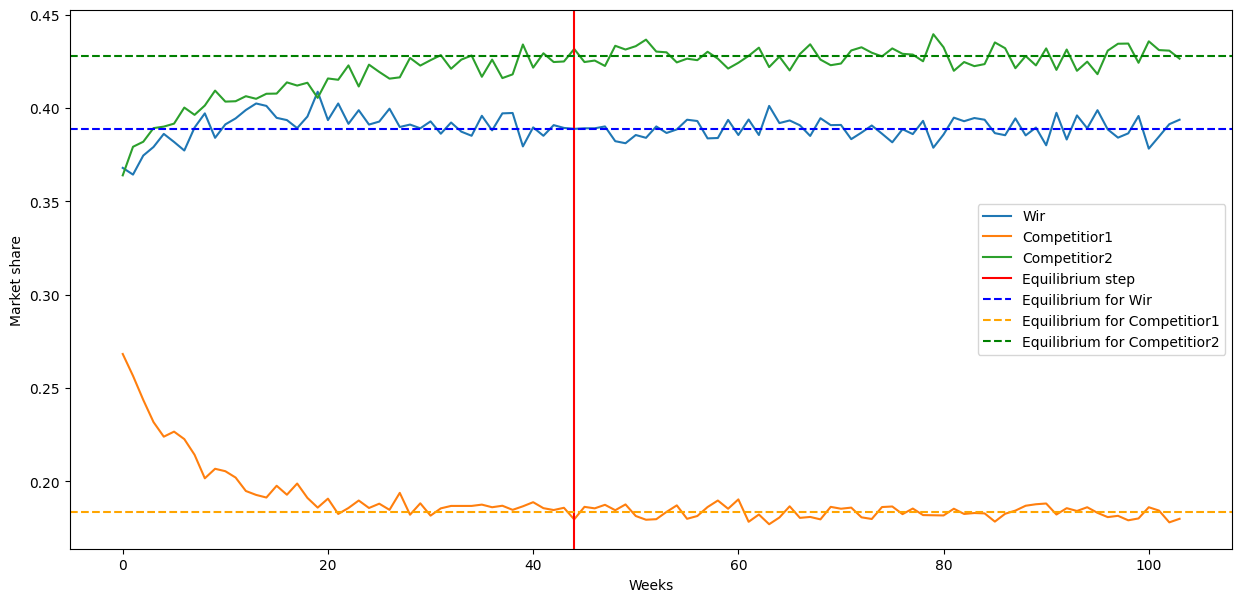

In [365]:
colors = ['blue', 'orange', 'green']

fig, ax = plt.subplots(figsize=(15, 7))

plt.plot(market_share_history, label=list(map(lambda x: x.name, providers)))

plt.axvline(eq_step, color='red', label='Equilibrium step')

for i, sh in enumerate(eq_shares):
    plt.axhline(sh, linestyle='dashed', linewidth=1.5, label=f'Equilibrium for {providers[i].name}', color=colors[i])

plt.xlabel("Weeks")
plt.ylabel("Market share")
plt.legend()